# Notebook 4 - Decision Tree & Random Forest

This notebook develops and evaluates Decision Tree and Random Forest regression models for predicting residential property close prices.

The models are trained using the same chronological, leakage-aware training and testing datasets used for the Linear Regression baseline. Their predictive performance is evaluated using R², MAE, MAPE, MdAPE, and RMSE, and the results are compared against the baseline model.

## Week 5 Summary

- Trained a Decision Tree Regressor to capture nonlinear relationships in property data.
- Evaluated multiple maximum-depth values for the Decision Tree and selected the strongest-performing configuration.
- Trained a Random Forest Regressor using multiple decision trees to improve predictive stability and reduce overfitting.
- Evaluated both models using R², MAE, MAPE, MdAPE, and RMSE.
- Compared model performance against the Linear Regression baseline.
- Visualized the Decision Tree structure and examined model feature importance.
- Considered both predictive accuracy and computational efficiency when selecting model parameters.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
from pathlib import Path
# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
test_encoded_df = dfs["test_encoded"]
print(f"Training Window: {TRAIN_MONTHS} months")

Training Window: 30 months


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317401, 107)
Test Set shape: (11646, 107)


## Prepare Features and Target

In [5]:
# Training set
x_train = train_encoded_df.drop(columns = ["ClosePrice"])
y_train = train_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print(x_train.shape)
print(x_test.shape)

(317401, 106)
(11646, 106)


## Target Variable Summary

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]
def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"
target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"317,401"
mean,"$1,189,779.56"
std,"$945,850.98"
min,"$189,000.00"
25%,"$620,000.00"
50%,"$887,000.00"
75%,"$1,415,000.00"
max,"$8,200,000.00"


## Train Decision Tree Model

### Test different depth of Tree

To identify an appropriate level of model complexity, multiple maximum tree depths were evaluated while keeping the remaining hyperparameters fixed. The configuration with the highest test R² was selected for the final Decision Tree model.

In [8]:
# Find the best depth of Tree
depth_results = []
for depth in [3, 5, 8, 10, 12, 15, 20]:
    model = DecisionTreeRegressor(
        max_depth = depth, 
        min_samples_split = 10,
        min_samples_leaf = 5,
        random_state = 42
    )
    model.fit(x_train, y_train)
    y_pred_depth = model.predict(x_test)
    depth_results.append({
        "Max Depth": depth,
        "R²": r2_score(y_test, y_pred_depth),
        "MAE": mean_absolute_error(y_test, y_pred_depth)
    })
depth_results_df = pd.DataFrame(depth_results)
depth_results_df.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}"
}).hide(axis = "index")

Max Depth,R²,MAE
3,0.4267,"$498,635.07"
5,0.5352,"$417,694.04"
8,0.6610,"$334,485.58"
10,0.7259,"$291,051.50"
12,0.7644,"$258,207.06"
15,0.8004,"$225,561.64"
20,0.8130,"$208,460.26"


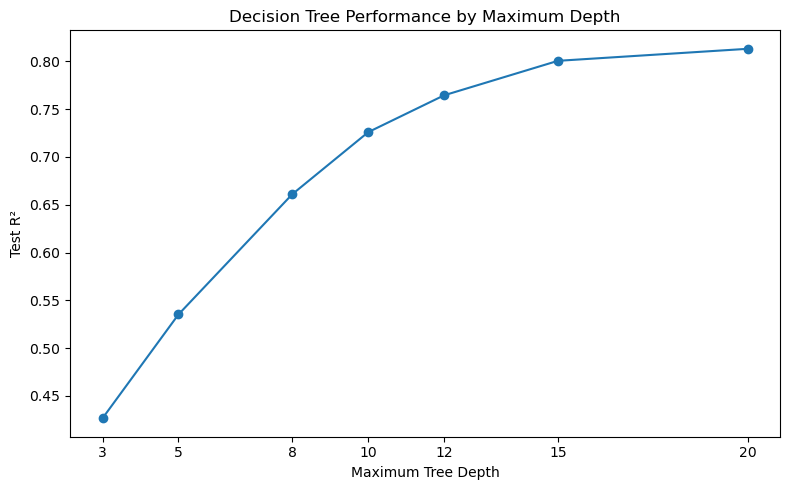

In [9]:
plt.figure(figsize = (8, 5))
plt.plot(depth_results_df["Max Depth"], depth_results_df["R²"], marker = "o")
plt.xlabel("Maximum Tree Depth")
plt.ylabel("Test R²")
plt.title("Decision Tree Performance by Maximum Depth")
plt.xticks(depth_results_df["Max Depth"])
plt.tight_layout()
plt.show()

The Decision Tree performance improved consistently as the maximum depth increased. The improvement became smaller at larger depths, indicating diminishing returns from additional model complexity. Among the evaluated configurations, a maximum depth of 20 achieved the highest test R² and was therefore selected for the final model.

In [10]:
best_depth = int(depth_results_df.loc[depth_results_df["R²"].idxmax(), "Max Depth"])
print(f"Best max depth based on test R²: {best_depth}")

Best max depth based on test R²: 20


### Rerun the Decision Tree model

In [11]:
# Initialize Decision Tree Model with the best_depth we found
dt_regressor = DecisionTreeRegressor(
    max_depth = best_depth, 
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 42
)
dt_regressor.fit(x_train, y_train)
print("Decision Tree training completed.")

Decision Tree training completed.


## Generate Predictions

In [12]:
y_pred_dt = dt_regressor.predict(x_test)

## Decision Tree Visualization

The first three levels of the trained Decision Tree are visualized below.  
Only the upper levels are displayed to preserve readability because the complete tree contains a large number of nodes and branches.

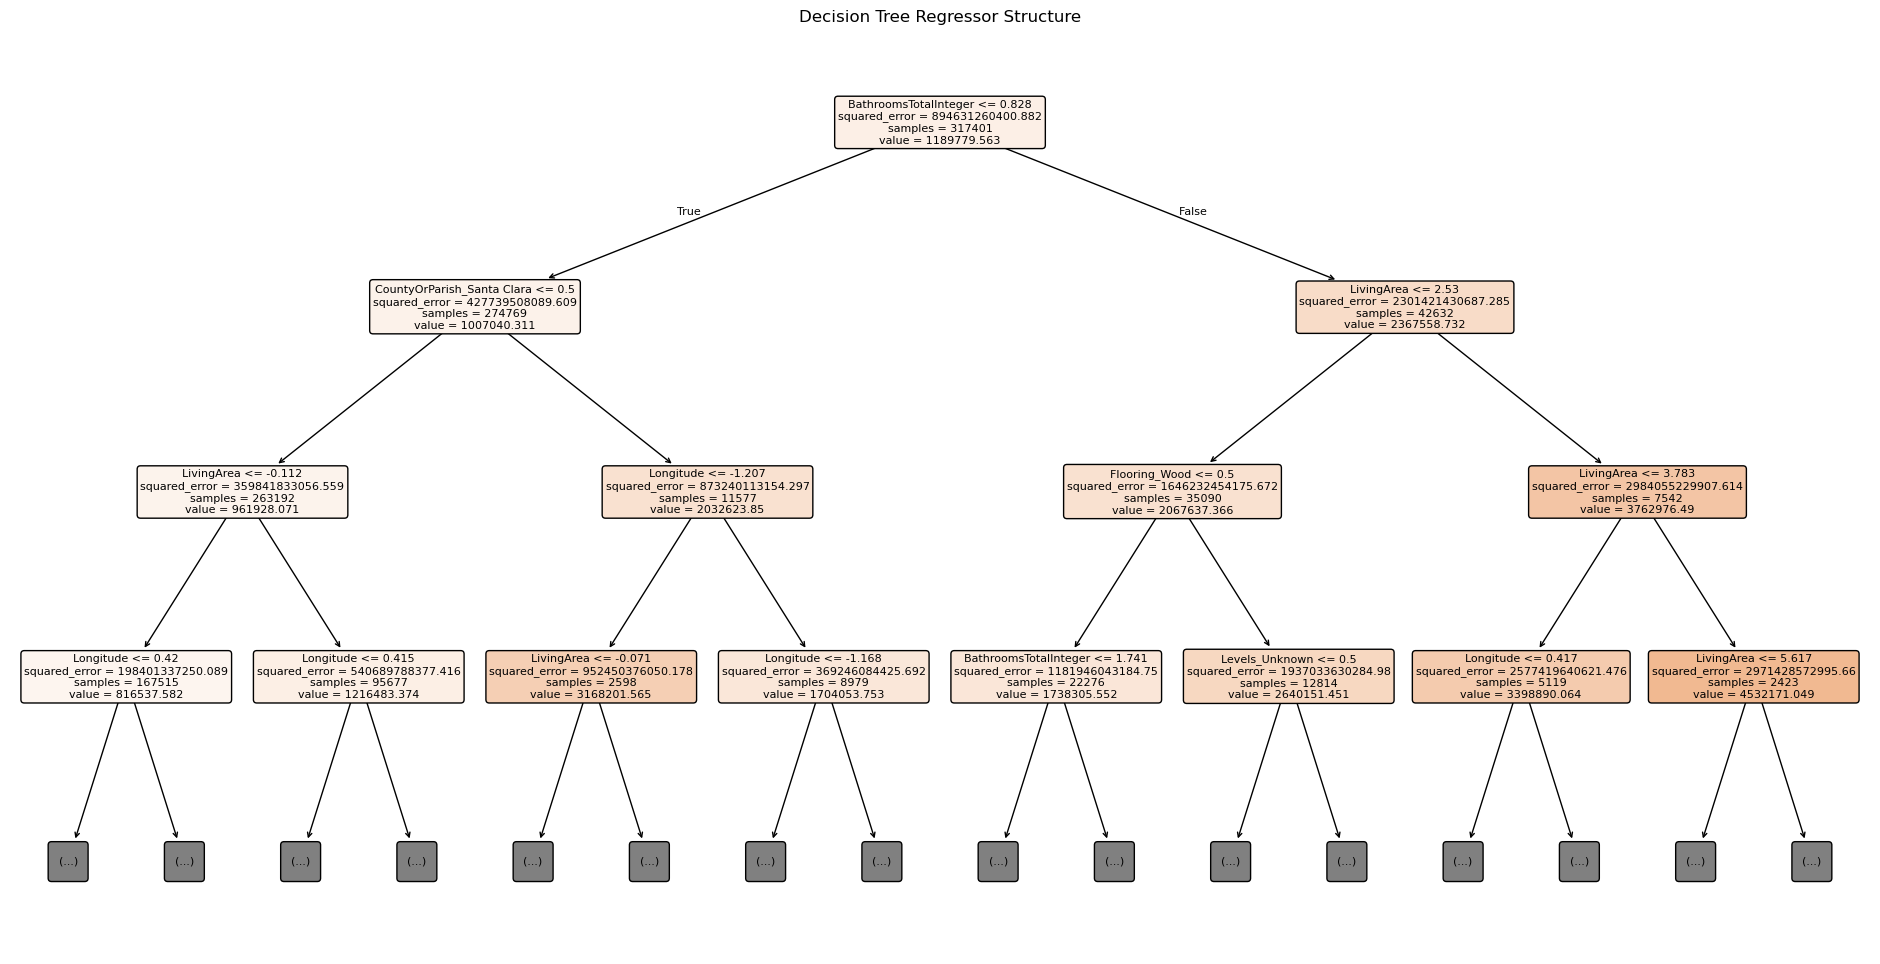

In [13]:
plt.figure(figsize = (24, 12))
plot_tree(dt_regressor, feature_names = x_train.columns, filled = True, rounded = True, max_depth = 3, fontsize = 8)
plt.title("Decision Tree Regressor Structure")
plt.show()

## Decision Tree Feature Importance

The feature importance scores below indicate the relative contribution of each feature to the Decision Tree's predictions. Higher importance values represent features that contribute more frequently to reducing prediction error during tree construction.

In [14]:
dt_feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": dt_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
dt_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.266534
5,Longitude,0.187045
6,LivingArea,0.164391
4,Latitude,0.162884
69,CountyOrParish_Santa Clara,0.048042
100,Flooring_Wood,0.041951
9,YearBuilt,0.014469
19,LotSizeSquareFeet,0.013716
59,CountyOrParish_Riverside,0.013227
14,LotSizeArea,0.011862


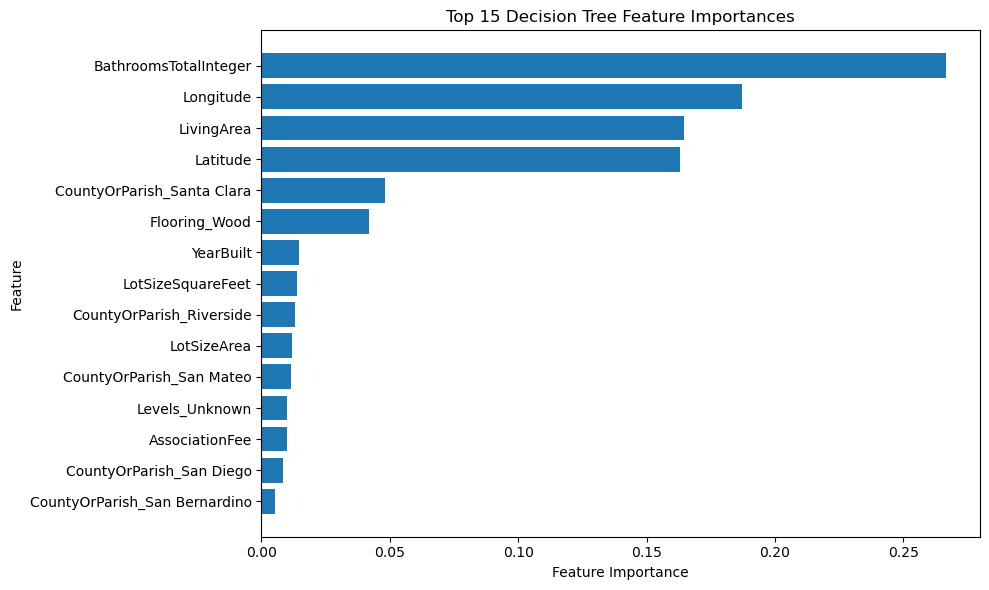

In [15]:
plt.figure(figsize = (10, 6))
plt.barh(dt_feature_importance["Feature"][::-1], dt_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

## Train Random Forest Model

The Random Forest feature importance represents the average contribution of each feature across all decision trees in the ensemble. Compared with a single Decision Tree, these importance values are generally more stable and less sensitive to individual splits.

In [16]:
rf_regressor = RandomForestRegressor(
    n_estimators = 50, 
    max_depth = 15, 
    min_samples_split = 10,
    min_samples_leaf = 5,
    n_jobs = -1,
    random_state = 42
)
rf_regressor.fit(x_train, y_train)
print("Random Forest training completed.")

Random Forest training completed.


## Generate Predictions

In [17]:
y_pred_rf = rf_regressor.predict(x_test)

## Random Forest Feature Importance

In [18]:
rf_feature_importance = pd.DataFrame({"Feature": x_train.columns, "Importance": rf_regressor.feature_importances_})\
    .sort_values("Importance", ascending = False).head(15)
rf_feature_importance

,Feature,Importance
10,BathroomsTotalInteger,0.276324
5,Longitude,0.179719
6,LivingArea,0.170684
4,Latitude,0.159554
69,CountyOrParish_Santa Clara,0.050380
100,Flooring_Wood,0.040949
9,YearBuilt,0.014813
67,CountyOrParish_San Mateo,0.013050
19,LotSizeSquareFeet,0.011874
18,AssociationFee,0.010462


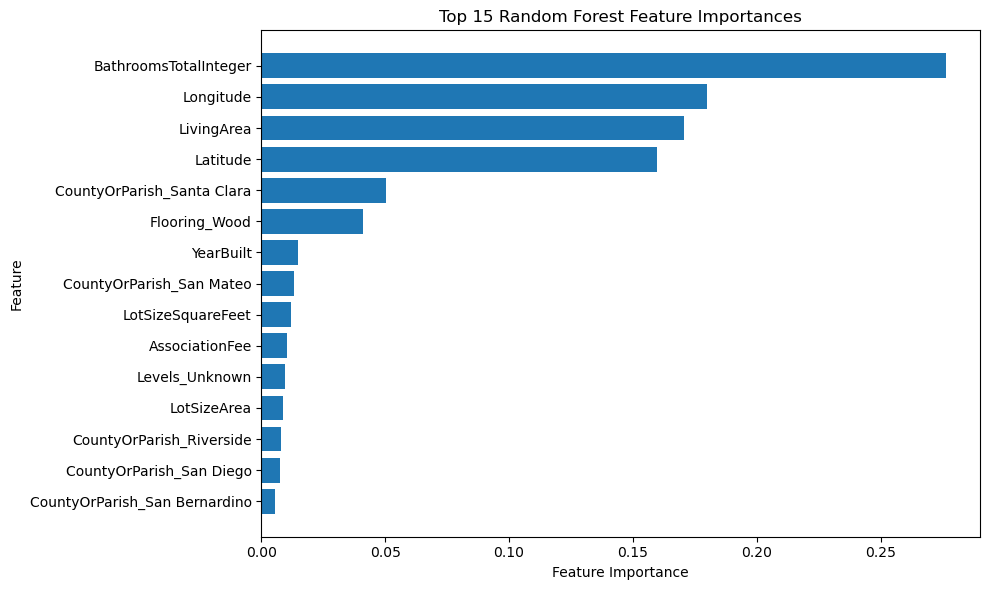

In [19]:
plt.figure(figsize = (10, 6))
plt.barh(rf_feature_importance["Feature"][::-1], rf_feature_importance["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## Evaluate Model Performance

In [20]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [21]:
r2_dt, mae_dt, mape_dt, mdape_dt, rmse_dt = evaluation(y_test, y_pred_dt)

In [22]:
r2_rf, mae_rf, mape_rf, mdape_rf, rmse_rf = evaluation(y_test, y_pred_rf)

## Results

### Regenerate Linear Regression Results

In [23]:
lr_regressor = LinearRegression()
lr_regressor.fit(x_train, y_train)
y_pred_lr = lr_regressor.predict(x_test)
r2_lr, mae_lr, mape_lr, mdape_lr, rmse_lr = evaluation(y_test, y_pred_lr)

In [24]:
# Organize Results to dataframe
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor"],
    "R²": [r2_lr, r2_dt, r2_rf],
    "MAE": [mae_lr, mae_dt, mae_rf],
    "MAPE (%)": [mape_lr, mape_dt, mape_rf],
    "MdAPE (%)": [mdape_lr, mdape_dt, mdape_rf],
    "RMSE": [rmse_lr, rmse_dt, rmse_rf]
})
# Convert to Dataframe
results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6405,"$368,707.93",33.8549%,25.1820%,"$586,081.35"
Decision Tree Regressor,0.8130,"$208,460.26",15.1352%,9.9675%,"$422,718.61"
Random Forest Regressor,0.8609,"$192,948.57",14.8471%,10.1211%,"$364,520.98"


## Normalized Model Performance Comparison

Because the evaluation metrics use different units and scales, they cannot be compared directly on a single axis. Each metric is therefore converted into a relative performance score, where 1.0 represents the best-performing model for that metric and higher values indicate stronger performance.

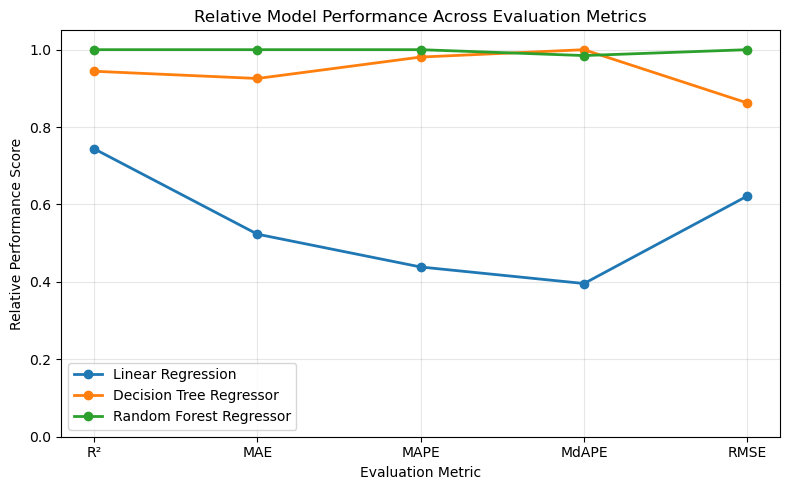

In [25]:
comparison_scores = pd.DataFrame({
    "Model": results["Model"],
    "R²": results["R²"] / results["R²"].max(),
    "MAE": results["MAE"].min() / results["MAE"],
    "MAPE": results["MAPE (%)"].min() / results["MAPE (%)"],
    "MdAPE": results["MdAPE (%)"].min() / results["MdAPE (%)"],
    "RMSE": results["RMSE"].min() / results["RMSE"]
}).set_index("Model")
plt.figure(figsize = (8, 5))
for model in comparison_scores.index:
    plt.plot(comparison_scores.columns, comparison_scores.loc[model], marker = "o", linewidth = 2, label = model)
plt.ylim(0, 1.05)
plt.ylabel("Relative Performance Score")
plt.xlabel("Evaluation Metric")
plt.title("Relative Model Performance Across Evaluation Metrics")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Actual vs Predicted Plot

### Decision Tree

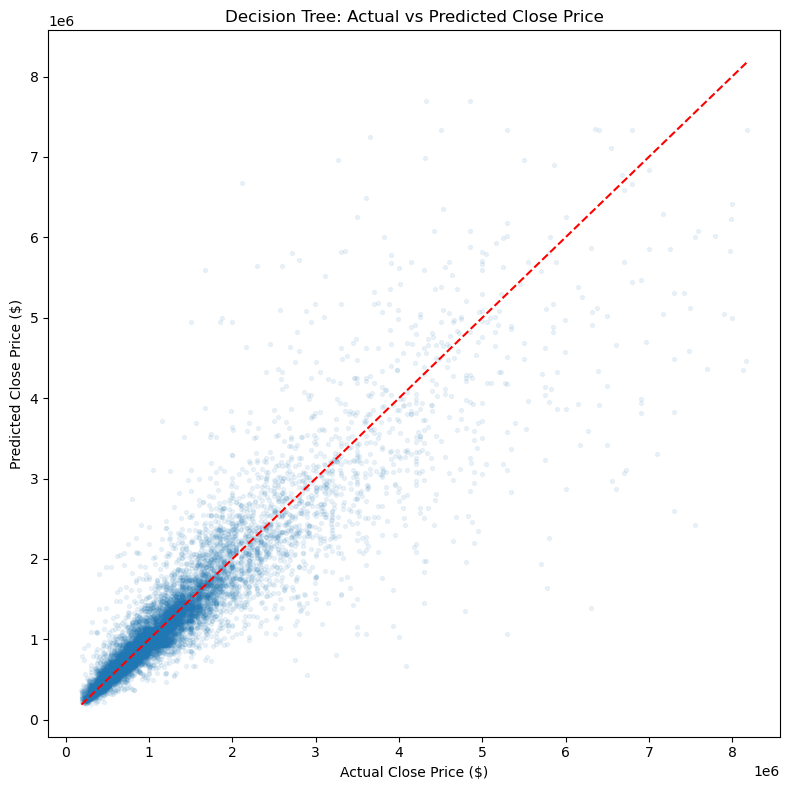

In [26]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_dt, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Decision Tree: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

### Random Forest

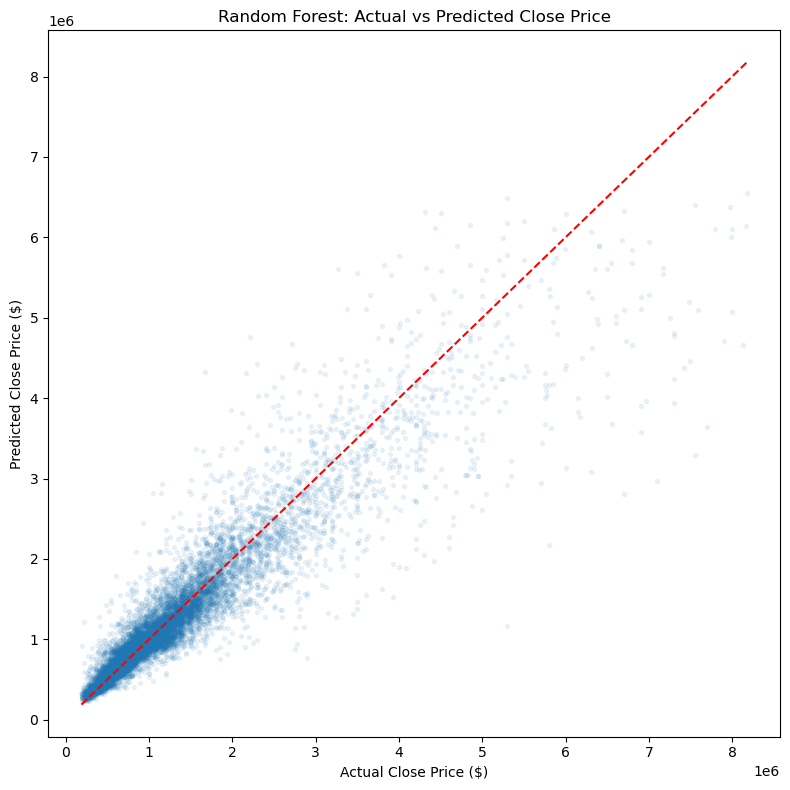

In [27]:
plt.figure(figsize = (8, 8))
plt.scatter(y_test, y_pred_rf, alpha = 0.08, s = 8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linestyle = "--")
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Random Forest: Actual vs Predicted Close Price")
plt.tight_layout()
plt.show()

## Evaluation Summary

The Decision Tree and Random Forest models substantially outperformed the Linear Regression baseline on the held-out testing dataset.

The Decision Tree Regressor increased the R² score from 0.6405 to 0.8130, indicating that nonlinear relationships between property characteristics and sale prices were successfully captured. Compared with the baseline, both MAE and RMSE decreased considerably, demonstrating a substantial improvement in prediction accuracy.

The Random Forest Regressor achieved the strongest overall performance, with an R² score of 0.8609, an MAE of USD 192,948.57, and an RMSE of USD 364,520.98. By aggregating predictions from multiple decision trees, the Random Forest produced more stable predictions and reduced large prediction errors compared with a single Decision Tree.

Although the Decision Tree achieved a slightly lower MdAPE than the Random Forest, the Random Forest produced the strongest overall performance based on R², MAE, and RMSE, making it the strongest candidate for subsequent feature engineering and advanced model development.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship